# BBC News Classification Kaggle Mini-Project

In this assignment, we will use matrix factorization to predict the category of a news article.

## Importing Data and Brief EDA

Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis? 

Please feel free to look at online resources on processing raw texts to feature vectors. Many methods process texts to matrix form (word embedding), including TF-IDF, GloVe, Word2Vec, etc. Pick a method and process the raw texts to word embedding. Briefly explain the method(s) and how they work in your own words. Also, do exploratory data analysis such as word statistics and/or visualization.

As we did not learn natural language processing (NLP) specific techniques such as word embeddings in the lectures, we recommend reading discussions and example codes from others in the Kaggle and/or doing some research online to make sure you understand. You can refer to any resource as needed, but make sure you “demonstrate” your understanding- please include explaining in your own words, discussions, and your interpretation. Also importantly, please have a reference list at the end of the report. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from time import time
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
bbc_test = pd.read_csv('bbcnewstest.csv')
bbc_train = pd.read_csv('bbcnewstrain.csv')

In [3]:
bbc_train

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business
...,...,...,...
1485,857,double eviction from big brother model caprice...,entertainment
1486,325,dj double act revamp chart show dj duo jk and ...,entertainment
1487,1590,weak dollar hits reuters revenues at media gro...,business
1488,1587,apple ipod family expands market apple has exp...,tech


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


<Axes: xlabel='Category'>

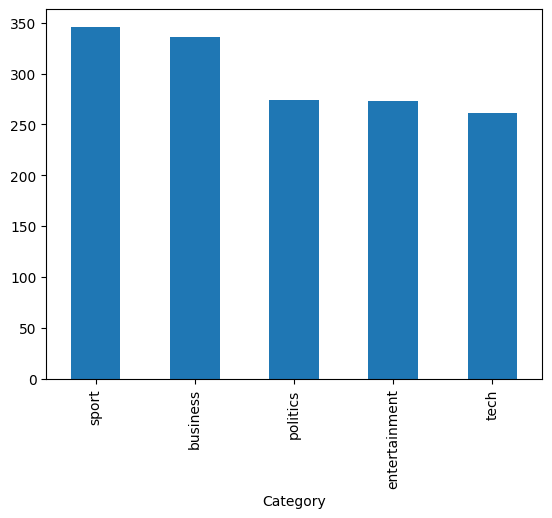

In [4]:
print(bbc_train.info())
bbc_train['Category'].value_counts().plot(kind = "bar")


In [5]:
X_train = bbc_train['Text']
y_train = bbc_train['Category']


Now we need to do some data preprocessing to turn the text into "numerical" data.  

In [ ]:

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_train)
print(X)
vectorizer.get_feature_names_out()


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 213866 stored elements and shape (1490, 24456)>
  Coords	Values
  (0, 24187)	0.49389312320548195
  (0, 8401)	0.08289314080278484
  (0, 3616)	0.03638612576344087
  (0, 12970)	0.05416878571127764
  (0, 6543)	0.04042165657730414
  (0, 12999)	0.14705326655985523
  (0, 6551)	0.04901775551995174
  (0, 4738)	0.08225808074242229
  (0, 3191)	0.05839125068723239
  (0, 7743)	0.34430610834747316
  (0, 2965)	0.054877013689497996
  (0, 9445)	0.17204131369534081
  (0, 4639)	0.12126496973191242
  (0, 4165)	0.028519043809447787
  (0, 5298)	0.0529416199197389
  (0, 23948)	0.07276527365464272
  (0, 24095)	0.11294700036681521
  (0, 6250)	0.06889036350113473
  (0, 5771)	0.22256783272138428
  (0, 10656)	0.03455565170481055
  (0, 11909)	0.052892665673459745
  (0, 1336)	0.348945082661093
  (0, 1750)	0.06400855405163985
  (0, 7039)	0.047544583050883306
  (0, 12077)	0.0661410709942484
  :	:
  (1489, 13757)	0.15597873460683187
  (1489, 17618)	0.130000

array(['00', '000', '0001', ..., 'zurich', 'zutons', 'zvonareva'],
      dtype=object)

## Model Building and Training (Unsupervised)

In the Kaggle competition, the training data has labels (category). Thus, it can be solved using supervised learning. In general, the more labeled data we have, the more accurate the supervised learning model will be. But unsupervised learning can be powerful even when there is a small number of labels or no labels. This assignment will apply an unsupervised approach, especially the matrix factorization method, to discover topics in the news articles and use the labels to check the accuracy.

Here are some steps to guide this section: 
1) Think about this and answer: when you train the unsupervised model for matrix factorization, should you include texts (word features) from the test dataset or not as the input matrix? Why or why not?
2) Build a model using the matrix factorization method(s) and predict the train and test data labels. Choose any hyperparameter (e.g., number of word features) to begin with.
3) Measure the performances on predictions from both train and test datasets. You can use accuracy, confusion matrix, etc., to inspect the performance. You can get accuracy for the test data by submitting the result to Kaggle. 
4) Change hyperparameter(s) and record the results. We recommend including a summary table and/or graphs.
5) Improve the model performance if you can- some ideas may include but are not limited to; using different feature extraction methods, fit models in different subsets of data, ensemble the model prediction results, etc. 

In [1]:
# Use sklearn matric factorization

## Supervised methods for comparison

Use the following steps to guide your work:

1) Pick and train a supervised learning method(s) and compare the results (train and test performance)
2) Discuss comparison with the unsupervised approach. You may try changing the train data size (e.g., Include only 10%, 20%, 50% of labels, and observe train/test performance changes). Which methods are data-efficient (require a smaller amount of data to achieve similar results)? What about overfitting?

## Results and comparisons